In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Multiple regression

Vi ønsker at fitte data ved brug af en model af formen
$$
y = \alpha + \beta_1x_1 + ... + \beta_d x_d 
$$
Bemærk, vi benytter også de binære variable i denne model, men de ender med bare at fungerer som interceptled hvis vi har at $x_2$ er binær har vi
\begin{align*}
x_2 = 0 \Rightarrow \\
y = \alpha  + \beta_1x_1 + \beta_2 x_2 
\end{align*}
eller vi har
\begin{align*}
x_2 = 1 \Rightarrow \\
y &= \alpha  + \beta_1x_1 + \beta_2 \cdot 1 \\
&= (\alpha + \beta_2) + beta_1 x_1
\end{align*}

Til at fitte modeller benytter vi scikit-learn


In [2]:
# load data
df = pd.read_csv(r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\raw\synthetic_dataset_A_non-iid.csv")
df["Complication"] = ((df["Risk_AlveolarOsteitis"] == 0) & 
                    (df["Risk_SecondaryInfection"] == 0) & 
                    (df["Risk_NerveDysesthesia"] == 0) & 
                    (df["Risk_Bleeding"] == 0)).astype(int)

In [3]:
variables = df.columns[1:27].tolist()
print(variables)
print(df.columns[24])

# Vi standardisere vores features.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Kun de kolonner du vil skalere
df[variables] = scaler.fit_transform(df[variables])

['Patient', 'Age', 'Sex', 'Pain', 'Swelling', 'Trismus', 'Pericoronitis', 'Caries_Wisdom', 'Caries_Adjacent', 'Periodontal_Status', 'Root_Development', 'Tooth_Mobility', 'Tooth_Angulation', 'Impaction_Depth', 'Proximity_Nerve', 'Root_Count', 'Root_Curvature', 'Bone_Density', 'Cyst', 'Diabetes', 'Osteoporosis', 'Clotting_Disorder', 'Smoking', 'Bisphosphonates', 'Prev_Extraction_Issue', 'Surgical_Extraction_Type']
Bisphosphonates


In [4]:
from sklearn.linear_model import LinearRegression as lr 

# list all variables that you want to include in the regression
variables = df.columns[1:27].tolist()

def multiple_regression(df, variables):
    '''
    Input: df (dataframe), variables (all the variables you want to include in the regression as a list)
    Returns: (intercept, [list of coefficients])
    '''
    n = len(df)
    d = len(variables)

    # construct empty design matrix
    X = np.zeros((n, d))

    # targets
    y = df["Complication"]

    # fill out design matrix 
    for i in range(d):
        X[:, i] = df[variables[i]]
    #make model
    model = lr()
    #fit model
    model.fit(X,  y)
    return model.intercept_, model.coef_

In [5]:
# function that plots the absolute values of the coefficients
def plot_magnitude(coefs, variable_names, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    magnitudes = np.abs(coefs)
    
    ax.bar(range(len(coefs)), magnitudes)
    
    ax.set_xticks(range(len(coefs)))
    ax.set_xticklabels(variable_names, rotation=90)
    
    ax.set_title(title)
    ax.set_xlabel("Variables")
    ax.set_ylabel("|Coefficient|")
    
    plt.tight_layout()
    plt.show()

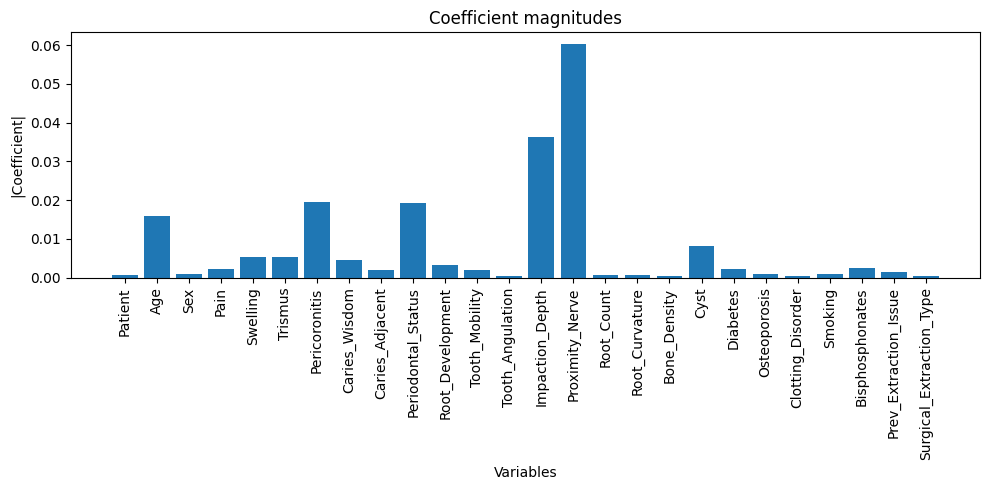

In [6]:
inter, coef = multiple_regression(df, variables)
plot_magnitude(coef, variables, title=f"Coefficient magnitudes")

# Multiple regression in FL

In [7]:
def FL_mul_reg(df, variables, num_clients, weighted = True):
    d = len(variables)
    k = num_clients
    n = len(df)
    all_coefs = np.zeros((k, d+2))
    for i in range(1, num_clients+1):
        client_data = df[df["Client"] == i]
        if len(client_data) > 0:
            inter, coefs = multiple_regression(client_data, variables)
            all_coefs[i-1, 0] = inter
            all_coefs[i-1, 1] = len(client_data)
            all_coefs[i-1, 2:] = coefs

    # vægtet gennemsnit
    if weighted:
        means_intercept = 0
        means_coefs = np.zeros(d)
        for i in range(k):
            means_intercept += all_coefs[i, 1] * all_coefs[i, 0]
        means_intercept /= n
        for i in range(d):
            for j in range(k):
                means_coefs[i] += all_coefs[j, 1] * all_coefs[j, i+2]
            means_coefs[i] /= n

    # det simple ikke-vægtede gennemsnit
    if not weighted:
        means_intercept = np.mean(all_coefs[:, 0])
        means_coefs = np.mean(all_coefs[:, 2:], axis=0)

    return means_intercept, means_coefs

        

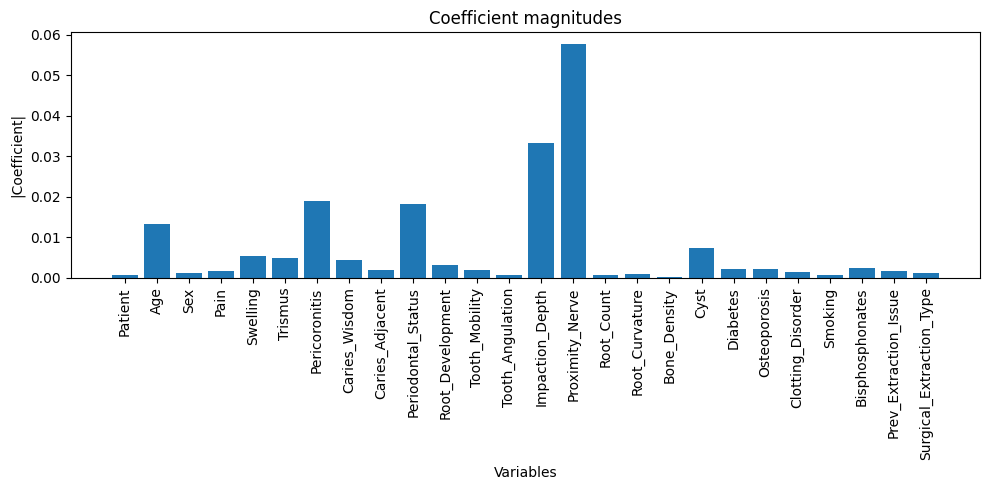

In [8]:
co = FL_mul_reg(df, variables, 10)
coefs = co[1]
plot_magnitude(coefs, variables, title=f"Coefficient magnitudes")

## One regression for each complication

In [9]:
variables = df.columns[1:27].tolist()

def multiple_regression_foreach(df,complication, variables):
    '''
    Input: df (dataframe), variables (all the variables you want to include in the regression as a list)
    Returns: (intercept, [list of coefficients])
    '''
    n = len(df)
    d = len(variables)

    # construct empty design matrix
    X = np.zeros((n, d))

    # targets
    y = df[complication]

    # fill out design matrix 
    for i in range(d):
        X[:, i] = df[variables[i]]
    
    #make model
    model = lr()
    #fit model
    model.fit(X,  y)
    return model.intercept_, model.coef_

def FL_mul_reg_foreach(df, variables,complication, num_clients, weighted = True):
    d = len(variables)
    k = num_clients
    n = len(df)
    all_coefs = np.zeros((k, d+2))
    for i in range(1, num_clients+1):
        client_data = df[df["Client"] == i]
        if len(client_data) > 0:
            inter, coefs = multiple_regression_foreach(client_data,complication, variables)
            all_coefs[i-1, 0] = inter
            all_coefs[i-1, 1] = len(client_data)
            all_coefs[i-1, 2:] = coefs

    # vægtet gennemsnit
    if weighted:
        means_intercept = 0
        means_coefs = np.zeros(d)
        for i in range(k):
            means_intercept += all_coefs[i, 1] * all_coefs[i, 0]
        means_intercept /= n
        for i in range(d):
            for j in range(k):
                means_coefs[i] += all_coefs[j, 1] * all_coefs[j, i+2]
            means_coefs[i] /= n

    # det simple ikke-vægtede gennemsnit
    if not weighted:
        means_intercept = np.mean(all_coefs[:, 0])
        means_coefs = np.mean(all_coefs[:, 2:], axis=0)

    return means_intercept, means_coefs


def foreach(df, variables, num_clients, complications):
    result = {}
    for complication in complications:
        intercept, coefs = FL_mul_reg_foreach(df, variables,complication, num_clients, weighted = True)
        result[complication] = (intercept, coefs)
    return result

In [10]:
import numpy as np
import pandas as pd

def predict_from_coefs(df, variables, intercept, coefs):
    """
    Beregner y-hat = intercept + X beta
    for alle rækker i df.
    """
    X = df[variables].to_numpy()
    y_hat = intercept + X @ coefs
    return y_hat

def assign_tertiles(y_hat):
    """
    Deler y_hat i 3 grupper baseret på 1/3 og 2/3 kvantiler.
    Returnerer både gruppe-labels og grænserne.
    """
    q1 = np.quantile(y_hat, 1/3)
    q2 = np.quantile(y_hat, 2/3)

    groups = np.where(
        y_hat <= q1, 0,
        np.where(y_hat <= q2, 1, 2)
    )

    return groups, q1, q2

def predict_and_group_all(test_df, variables, model_results):
    """
    model_results er fx output fra:
        results = foreach(df, variables, num_clients, complications)

    Returnerer et dataframe med predictions og gruppeinddeling
    for hver complication.
    """
    out = test_df.copy()
    cutoffs = {}

    for complication, (intercept, coefs) in model_results.items():
        y_hat = predict_from_coefs(test_df, variables, intercept, coefs)
        groups, q1, q2 = assign_tertiles(y_hat)

        out[f"{complication}_group"] = groups

        cutoffs[complication] = {
            "q1": q1,
            "q2": q2
        }

    return out, cutoffs



In [11]:
test_data = pd.read_csv(r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\processed\A\global_test_set_non-iid.csv")

test_data[variables] = scaler.transform(test_data[variables])


complications = [
    "Risk_AlveolarOsteitis",
    "Risk_SecondaryInfection",
    "Risk_NerveDysesthesia",
    "Risk_Bleeding"
]

variables = df.columns[1:27].tolist()

results = foreach(df, variables, 10, complications)

test_with_preds, cutoffs = predict_and_group_all(test_data, variables, results)


In [12]:
import numpy as np
import pandas as pd

def metrics_for_one_complication(df, complication):
    """
    complication fx 'Risk_AlveolarOsteitis'
    
    Bruger:
      true: Risk_Category_AlveolarOsteitis
      pred: Risk_AlveolarOsteitis_group
    """
    
    true_col = complication.replace("Risk_", "Risk_Category_", 1)
    pred_col = f"{complication}_group"
    
    y_true = df[true_col].to_numpy()
    y_pred = df[pred_col].to_numpy()
    
    results = {}
    
    for cls in [0, 1, 2]:
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        results[cls] = {
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }
    
    macro_f1 = np.mean([results[cls]["f1"] for cls in [0, 1, 2]])
    
    return {
        "true_col": true_col,
        "pred_col": pred_col,
        "per_class": results,
        "macro_f1": macro_f1
    }

def metrics_for_all_complications(df, complications):
    all_results = {}
    macro_f1s = []

    for complication in complications:
        res = metrics_for_one_complication(df, complication)
        all_results[complication] = res
        macro_f1s.append(res["macro_f1"])

    # svarer til f1_global_macro i din pipeline
    overall_macro_f1 = np.mean(macro_f1s)

    return all_results, overall_macro_f1

In [13]:
complications = [
    "Risk_AlveolarOsteitis",
    "Risk_SecondaryInfection",
    "Risk_NerveDysesthesia",
    "Risk_Bleeding"
]

results, overall_f1 = metrics_for_all_complications(test_with_preds, complications)

for complication, res in results.items():
    print(f"\n--- {complication} ---")
    print(f"True column: {res['true_col']}")
    print(f"Pred column: {res['pred_col']}")
    
    for cls in [0, 1, 2]:
        vals = res["per_class"][cls]
        print(
            f"Class {cls}: "
            f"Precision={vals['precision']:.3f}, "
            f"Recall={vals['recall']:.3f}, "
            f"F1={vals['f1']:.3f}"
        )
    
    print(f"Macro F1 = {res['macro_f1']:.3f}")

print("\n==============================")
print(f"FINAL F1 (mean over risks) = {overall_f1:.3f}")
print("==============================")


--- Risk_AlveolarOsteitis ---
True column: Risk_Category_AlveolarOsteitis
Pred column: Risk_AlveolarOsteitis_group
Class 0: Precision=0.764, Recall=0.792, F1=0.778
Class 1: Precision=0.533, Recall=0.519, F1=0.526
Class 2: Precision=0.707, Recall=0.701, F1=0.704
Macro F1 = 0.669

--- Risk_SecondaryInfection ---
True column: Risk_Category_SecondaryInfection
Pred column: Risk_SecondaryInfection_group
Class 0: Precision=0.698, Recall=0.728, F1=0.713
Class 1: Precision=0.549, Recall=0.528, F1=0.538
Class 2: Precision=0.740, Recall=0.739, F1=0.739
Macro F1 = 0.663

--- Risk_NerveDysesthesia ---
True column: Risk_Category_NerveDysesthesia
Pred column: Risk_NerveDysesthesia_group
Class 0: Precision=0.742, Recall=0.810, F1=0.775
Class 1: Precision=0.613, Recall=0.558, F1=0.584
Class 2: Precision=0.753, Recall=0.764, F1=0.758
Macro F1 = 0.706

--- Risk_Bleeding ---
True column: Risk_Category_Bleeding
Pred column: Risk_Bleeding_group
Class 0: Precision=0.531, Recall=0.619, F1=0.572
Class 1: Prec

## Centralized

In [14]:
from sklearn.linear_model import LinearRegression as lr
import numpy as np
import pandas as pd


def fit_centralized_models(train_df, variables, complications):
    """
    Fitter én lineær regression pr. complication.
    """
    models = {}

    n = len(train_df)
    d = len(variables)

    X_train = np.zeros((n, d))
    for i in range(d):
        X_train[:, i] = train_df[variables[i]]

    for complication in complications:
        y_train = train_df[complication].to_numpy()

        model = lr()
        model.fit(X_train, y_train)

        models[complication] = {
            "intercept": model.intercept_,
            "coef": model.coef_
        }

    return models


def predict_and_group_centralized(test_df, variables, models):
    """
    Laver predictions og kvatil-grupper for hver complication på test_df.
    
    Tilføjer for hver complication:
      - Risk_XXX_group
    
    Returnerer:
      out_df, cutoffs
    """
    out = test_df.copy()
    cutoffs = {}

    n = len(test_df)
    d = len(variables)

    X_test = np.zeros((n, d))
    for i in range(d):
        X_test[:, i] = test_df[variables[i]]

    for complication, params in models.items():
        intercept = params["intercept"]
        coefs = params["coef"]

        y_hat = intercept + X_test @ coefs

        q1 = np.quantile(y_hat, 1/3)
        q2 = np.quantile(y_hat, 2/3)

        groups = np.where(
            y_hat <= q1, 0,
            np.where(y_hat <= q2, 1, 2)
        )

        out[f"{complication}_group"] = groups

        cutoffs[complication] = {
            "q1": q1,
            "q2": q2
        }

    return out, cutoffs


def run_centralized_baseline(train_df, test_df, variables, complications):
    """
    Samlet pipeline:
      1. fit modeller på train
      2. predict + group på test
      3. beregn F1 med dine eksisterende metric-funktioner
    
    Returnerer en dictionary med alt relevant output.
    """
    models = fit_centralized_models(train_df, variables, complications)
    test_with_preds, cutoffs = predict_and_group_centralized(test_df, variables, models)
    results, overall_macro_f1 = metrics_for_all_complications(test_with_preds, complications)

    return {
        "models": models,
        "test_with_preds": test_with_preds,
        "cutoffs": cutoffs,
        "results": results,
        "overall_macro_f1": overall_macro_f1
    }




complications = [
    "Risk_AlveolarOsteitis",
    "Risk_SecondaryInfection",
    "Risk_NerveDysesthesia",
    "Risk_Bleeding"
]

variables = df.columns[1:27].tolist()

centralized_output = run_centralized_baseline(
    train_df=df,
    test_df=test_data,
    variables=variables,
    complications=complications
)

results = centralized_output["results"]
overall_f1 = centralized_output["overall_macro_f1"]
test_with_preds_centralized = centralized_output["test_with_preds"]

for complication, res in results.items():
    print(f"\n--- {complication} ---")
    print(f"True column: {res['true_col']}")
    print(f"Pred column: {res['pred_col']}")

    for cls in [0, 1, 2]:
        vals = res["per_class"][cls]
        print(
            f"Class {cls}: "
            f"Precision={vals['precision']:.3f}, "
            f"Recall={vals['recall']:.3f}, "
            f"F1={vals['f1']:.3f}"
        )

    print(f"Macro F1 = {res['macro_f1']:.3f}")

print("\n==============================")
print(f"CENTRALIZED FINAL F1 = {overall_f1:.3f}")
print("==============================")


--- Risk_AlveolarOsteitis ---
True column: Risk_Category_AlveolarOsteitis
Pred column: Risk_AlveolarOsteitis_group
Class 0: Precision=0.762, Recall=0.790, F1=0.776
Class 1: Precision=0.542, Recall=0.528, F1=0.535
Class 2: Precision=0.716, Recall=0.710, F1=0.713
Macro F1 = 0.675

--- Risk_SecondaryInfection ---
True column: Risk_Category_SecondaryInfection
Pred column: Risk_SecondaryInfection_group
Class 0: Precision=0.697, Recall=0.727, F1=0.712
Class 1: Precision=0.545, Recall=0.525, F1=0.535
Class 2: Precision=0.742, Recall=0.741, F1=0.741
Macro F1 = 0.662

--- Risk_NerveDysesthesia ---
True column: Risk_Category_NerveDysesthesia
Pred column: Risk_NerveDysesthesia_group
Class 0: Precision=0.748, Recall=0.817, F1=0.781
Class 1: Precision=0.619, Recall=0.564, F1=0.590
Class 2: Precision=0.754, Recall=0.765, F1=0.759
Macro F1 = 0.710

--- Risk_Bleeding ---
True column: Risk_Category_Bleeding
Pred column: Risk_Bleeding_group
Class 0: Precision=0.543, Recall=0.633, F1=0.584
Class 1: Prec

MLP F1 macro aggregated: 0.6946, 0.7161 efter mlp update.

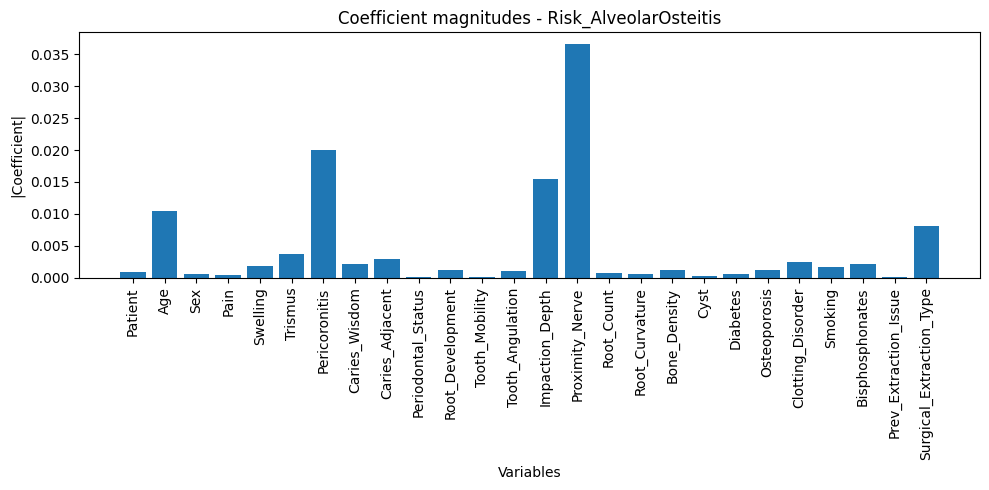

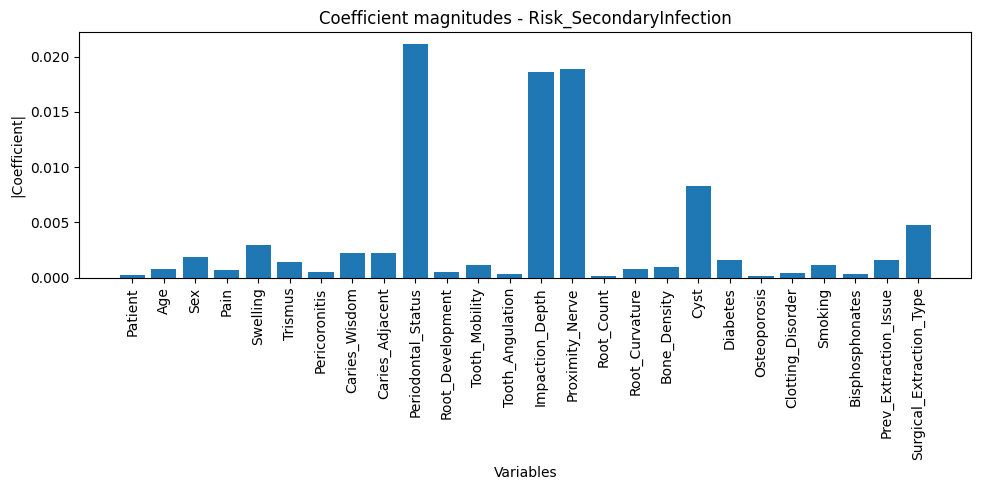

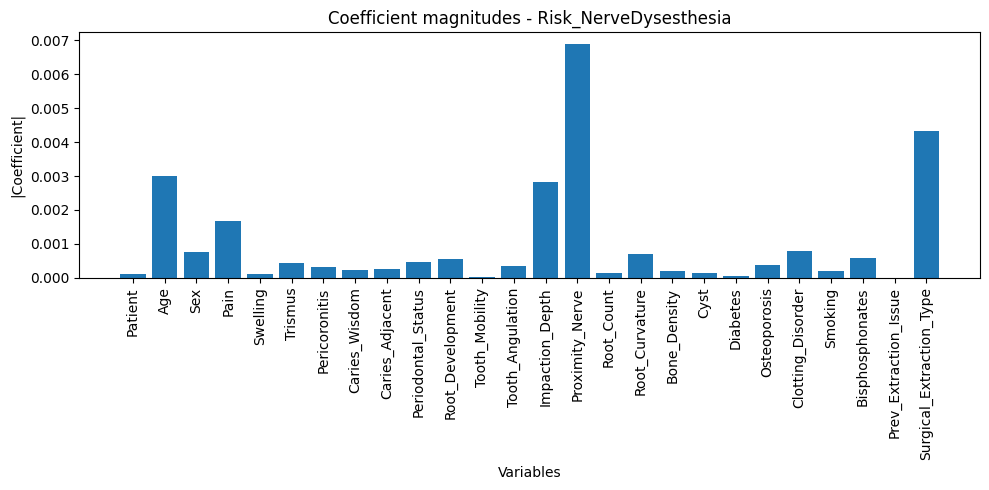

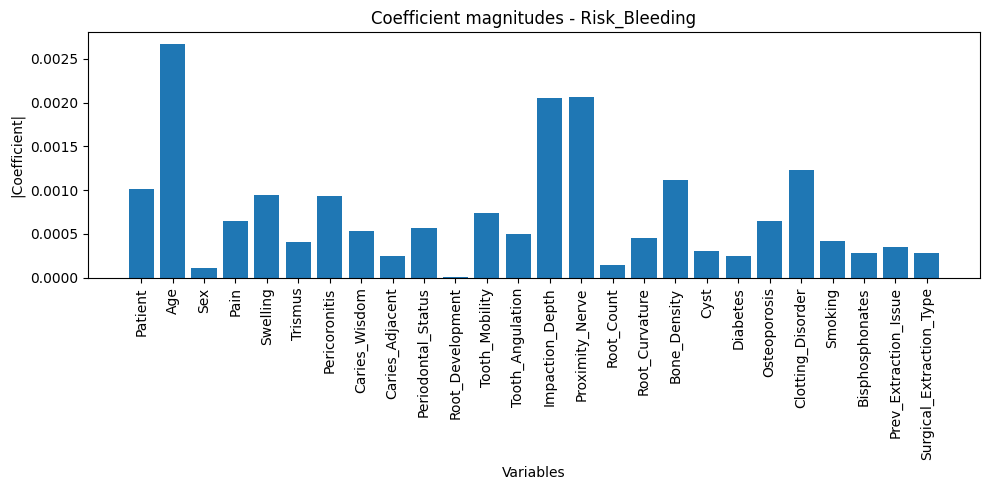

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_complications(results, variables):
    for complication, (intercept, coefs) in results.items():
        plot_magnitude(
            coefs,
            variables,
            title=f"Coefficient magnitudes - {complication}"
            )


results_fed = foreach(df, variables, 10, complications)
plot_all_complications(results_fed, variables)


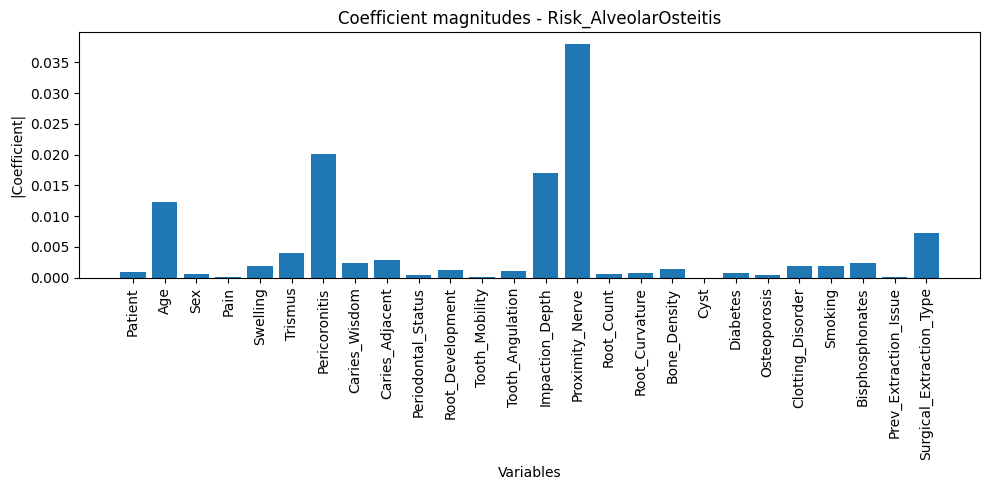

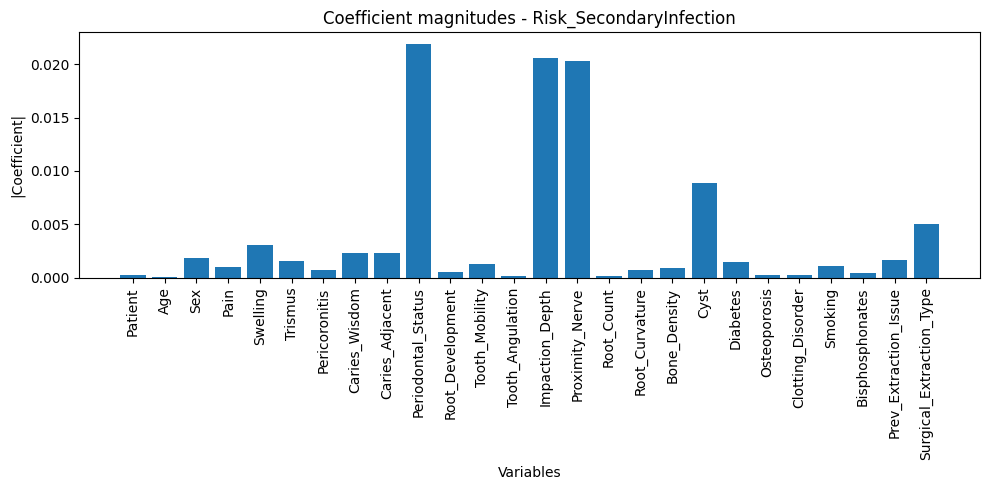

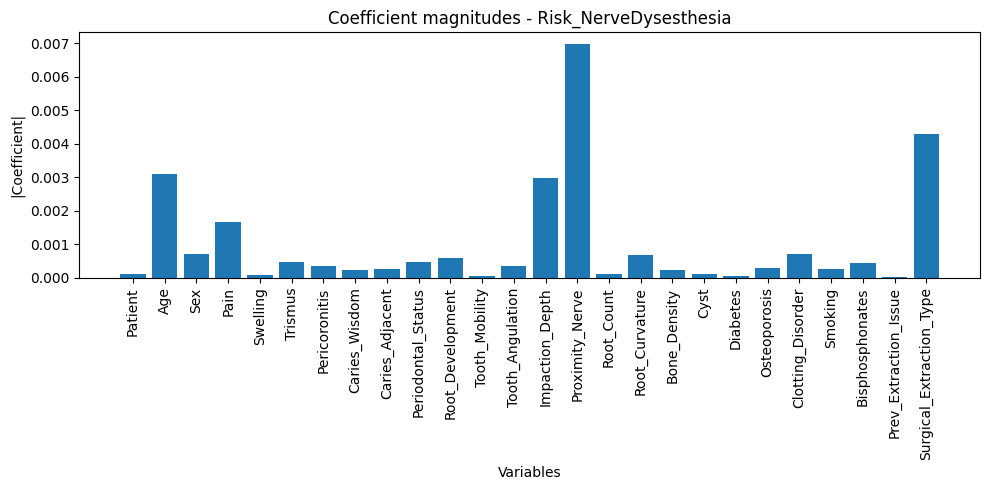

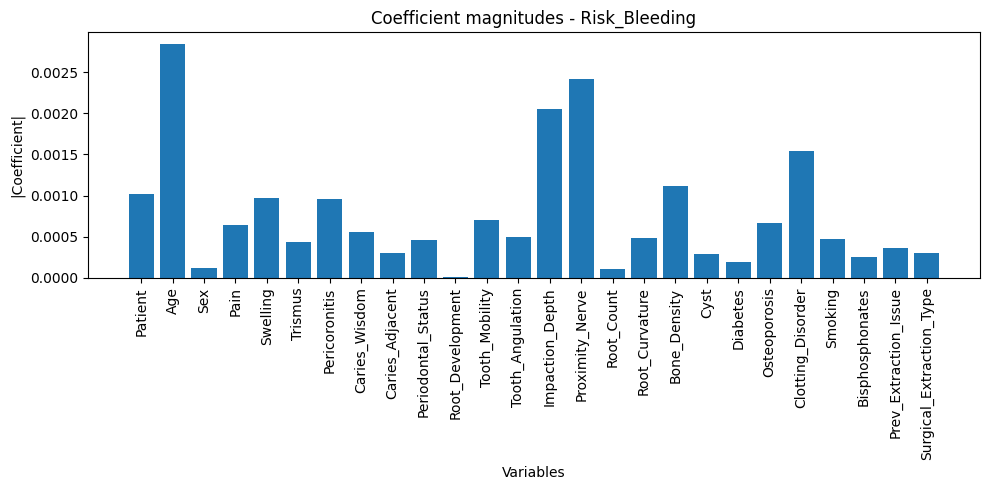

In [16]:

complications = [
    "Risk_AlveolarOsteitis",
    "Risk_SecondaryInfection",
    "Risk_NerveDysesthesia",
    "Risk_Bleeding"
]

variables = df.columns[1:27].tolist()

centralized_output = run_centralized_baseline(
    train_df=df,
    test_df=test_data,
    variables=variables,
    complications=complications
)

results_centralized = centralized_output["models"]

def plot_all_complications(results, variables):
    for complication, result_dict in results.items():
        plot_magnitude(
            result_dict["coef"],
            variables,
            title=f"Coefficient magnitudes - {complication}"
        )
plot_all_complications(results_centralized, variables)


Spørgsmål til ruben: hver komplication ligner at focusere på forskellige feachures, burde dette ikke afspejles bedre i vores MLP setup. Ligenu kører vi med fully connedted lag.

## Selection uden interaktioner centralized

In [17]:
# Backward:

import pandas as pd
import statsmodels.api as sm

def backward_elimination(X, y, alpha=0.05, verbose=True):
    """
    Backward elimination baseret på p-værdier.
    
    Parametre
    ---------
    X : pd.DataFrame
        Forklarende variable.
    y : pd.Series eller array-lignende
        Responsvariabel.
    alpha : float
        Signifikansniveau. Variable med p-værdi > alpha fjernes.
    verbose : bool
        Hvis True, printes hvilke variable der fjernes undervejs.
    
    Returnerer
    ----------
    selected_features : list
        Navne på de features der er tilbage.
    final_model : statsmodels-regression-resultat
        Den endelige fitted model.
    """
    
    X_selected = X.copy()
    
    while True:
        X_with_const = sm.add_constant(X_selected, has_constant="add")
        model = sm.OLS(y, X_with_const).fit()
        
        p_values = model.pvalues.drop("const", errors="ignore")
        max_p_value = p_values.max()
        
        if max_p_value > alpha:
            feature_to_remove = p_values.idxmax()
            if verbose:
                print(f"Fjerner '{feature_to_remove}' med p-værdi = {max_p_value:.4f}")
            X_selected = X_selected.drop(columns=[feature_to_remove])
        else:
            break
    
    final_X = sm.add_constant(X_selected, has_constant="add")
    final_model = sm.OLS(y, final_X).fit()
    
    return list(X_selected.columns), final_model

features, model = backward_elimination(df[variables], df["Risk_AlveolarOsteitis"])

Fjerner 'Cyst' med p-værdi = 0.9883
Fjerner 'Prev_Extraction_Issue' med p-værdi = 0.9628
Fjerner 'Tooth_Mobility' med p-værdi = 0.9448
Fjerner 'Pain' med p-værdi = 0.9347
Fjerner 'Osteoporosis' med p-værdi = 0.7625
Fjerner 'Periodontal_Status' med p-værdi = 0.7333
Fjerner 'Sex' med p-værdi = 0.6148
Fjerner 'Root_Count' med p-værdi = 0.6163
Fjerner 'Root_Curvature' med p-værdi = 0.5963
Fjerner 'Diabetes' med p-værdi = 0.5716
Fjerner 'Patient' med p-værdi = 0.4963
Fjerner 'Tooth_Angulation' med p-værdi = 0.3981
Fjerner 'Root_Development' med p-værdi = 0.3157
Fjerner 'Bone_Density' med p-værdi = 0.2779
Fjerner 'Swelling' med p-værdi = 0.1557
Fjerner 'Smoking' med p-værdi = 0.1395
Fjerner 'Clotting_Disorder' med p-værdi = 0.1330
Fjerner 'Caries_Wisdom' med p-værdi = 0.0724
Fjerner 'Bisphosphonates' med p-værdi = 0.0551


In [18]:
model.params

const                       0.088872
Age                         0.012257
Trismus                     0.004064
Pericoronitis               0.020224
Caries_Adjacent            -0.002893
Impaction_Depth             0.016990
Proximity_Nerve             0.037978
Surgical_Extraction_Type    0.007296
dtype: float64

In [19]:
import pandas as pd
import statsmodels.api as sm

def forward_selection(X, y, alpha=0.05, verbose=True):
    """
    Forward selection baseret på p-værdier.

    Parametre
    ---------
    X : pd.DataFrame
        Forklarende variable.
    y : pd.Series eller array-lignende
        Responsvariabel.
    alpha : float
        Signifikansniveau. En variabel tilføjes kun hvis p-værdien < alpha.
    verbose : bool
        Hvis True, printes hvilke variable der tilføjes undervejs.

    Returnerer
    ----------
    selected_features : list
        Navne på de features der er valgt.
    final_model : statsmodels-regression-resultat
        Den endelige fitted model.
    """

    remaining_features = list(X.columns)
    selected_features = []

    while remaining_features:
        pvals = {}

        for feature in remaining_features:
            features_to_test = selected_features + [feature]
            X_model = sm.add_constant(X[features_to_test], has_constant="add")
            model = sm.OLS(y, X_model).fit()
            pvals[feature] = model.pvalues[feature]

        best_feature = min(pvals, key=pvals.get)
        best_pval = pvals[best_feature]

        if best_pval < alpha:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            if verbose:
                print(f"Tilføjer '{best_feature}' med p-værdi = {best_pval:.4f}")
        else:
            break

    final_X = sm.add_constant(X[selected_features], has_constant="add")
    final_model = sm.OLS(y, final_X).fit()

    return selected_features, final_model

features, model = forward_selection(df[variables], df["Risk_AlveolarOsteitis"])

Tilføjer 'Proximity_Nerve' med p-værdi = 0.0000
Tilføjer 'Pericoronitis' med p-værdi = 0.0000
Tilføjer 'Impaction_Depth' med p-værdi = 0.0000
Tilføjer 'Age' med p-værdi = 0.0000
Tilføjer 'Surgical_Extraction_Type' med p-værdi = 0.0000
Tilføjer 'Trismus' med p-værdi = 0.0016
Tilføjer 'Caries_Adjacent' med p-værdi = 0.0252


In [20]:
model.params

const                       0.088872
Proximity_Nerve             0.037978
Pericoronitis               0.020224
Impaction_Depth             0.016990
Age                         0.012257
Surgical_Extraction_Type    0.007296
Trismus                     0.004064
Caries_Adjacent            -0.002893
dtype: float64

## Selection med interaktioner Centralized

In [21]:
import pandas as pd
from itertools import combinations

df_sub = df.copy()
X = df_sub[variables].copy()

interaction_cols = {}

for v1, v2 in combinations(variables, 2):
    interaction_cols[f"{v1}_x_{v2}"] = X[v1] * X[v2]

interaction_df = pd.DataFrame(interaction_cols, index=X.index)

design_df = pd.concat([X, interaction_df], axis=1)


In [22]:
df = df[:2500]
design_df = design_df[:2500]
features, model = backward_elimination(design_df, df["Risk_AlveolarOsteitis"])

Fjerner 'Root_Count_x_Root_Curvature' med p-værdi = 0.9960
Fjerner 'Age_x_Tooth_Mobility' med p-værdi = 0.9940
Fjerner 'Sex_x_Surgical_Extraction_Type' med p-værdi = 0.9924
Fjerner 'Smoking_x_Prev_Extraction_Issue' med p-værdi = 0.9918
Fjerner 'Pericoronitis_x_Cyst' med p-værdi = 0.9912
Fjerner 'Periodontal_Status_x_Root_Curvature' med p-værdi = 0.9903
Fjerner 'Caries_Wisdom_x_Bisphosphonates' med p-værdi = 0.9893
Fjerner 'Caries_Adjacent_x_Impaction_Depth' med p-værdi = 0.9885
Fjerner 'Sex_x_Diabetes' med p-værdi = 0.9868
Fjerner 'Tooth_Angulation_x_Cyst' med p-værdi = 0.9857
Fjerner 'Root_Development_x_Root_Curvature' med p-værdi = 0.9829
Fjerner 'Osteoporosis_x_Surgical_Extraction_Type' med p-værdi = 0.9768
Fjerner 'Cyst_x_Prev_Extraction_Issue' med p-værdi = 0.9721
Fjerner 'Pain_x_Root_Development' med p-værdi = 0.9697
Fjerner 'Patient_x_Surgical_Extraction_Type' med p-værdi = 0.9669
Fjerner 'Bisphosphonates_x_Surgical_Extraction_Type' med p-værdi = 0.9552
Fjerner 'Tooth_Mobility_x

In [23]:
features

['Age',
 'Pericoronitis',
 'Root_Development',
 'Proximity_Nerve',
 'Patient_x_Trismus',
 'Patient_x_Impaction_Depth',
 'Patient_x_Root_Count',
 'Age_x_Proximity_Nerve',
 'Sex_x_Root_Count',
 'Sex_x_Cyst',
 'Swelling_x_Root_Count',
 'Swelling_x_Prev_Extraction_Issue',
 'Swelling_x_Surgical_Extraction_Type',
 'Trismus_x_Proximity_Nerve',
 'Trismus_x_Cyst',
 'Pericoronitis_x_Proximity_Nerve',
 'Pericoronitis_x_Bone_Density',
 'Root_Development_x_Proximity_Nerve',
 'Tooth_Angulation_x_Clotting_Disorder',
 'Impaction_Depth_x_Proximity_Nerve',
 'Proximity_Nerve_x_Bone_Density',
 'Root_Count_x_Cyst',
 'Bone_Density_x_Cyst',
 'Cyst_x_Clotting_Disorder',
 'Diabetes_x_Surgical_Extraction_Type']

## Selection Centralized Lasso

In [24]:
from sklearn.linear_model import LinearRegression as lr
from sklearn.linear_model import Lasso
import numpy as np
import pandas as pd


def fit_centralized_models_lasso(train_df, variables, complications):
    """
    Fitter én lineær regression pr. complication.
    """
    models = {}

    n = len(train_df)
    d = len(variables)

    X_train = np.zeros((n, d))
    for i in range(d):
        X_train[:, i] = train_df[variables[i]]

    for complication in complications:
        y_train = train_df[complication].to_numpy()

        model = Lasso(alpha=0.0123, max_iter=10000)
        model.fit(X_train, y_train)

        models[complication] = {
            "intercept": model.intercept_,
            "coef": model.coef_
        }

    return models

design_df_merged = design_df.merge(df[["Patient",'Risk_AlveolarOsteitis',"Client"]], on = "Patient", how='left')

base_variables = [
    col for col in design_df_merged.columns
    if col not in ["Patient", "Client", "Risk_AlveolarOsteitis"]
]

centralized_lasso = fit_centralized_models_lasso(design_df_merged, base_variables, ["Risk_AlveolarOsteitis"])
sum([1 for a in centralized_lasso["Risk_AlveolarOsteitis"].get("coef") if a > 0])

17

In [25]:
def name_of_features(coefs, variabels):
    idx = []
    for i in range(len(coefs)):
        if coefs[i] > 0:
            idx.append(i)
    
    return [variabels[i] for i in idx]

centralized_lasso_names = name_of_features(centralized_lasso["Risk_AlveolarOsteitis"].get("coef"), base_variables)

## Selection uden interaktioner federated (Lasso)

Først omskriver vi vores FL model, så den virker med statsmodel:

In [26]:
import numpy as np
import pandas as pd


def soft_threshold(x, lam):
    """
    Prox-operator for L1 penalty.
    """
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0.0)


def client_update_lasso(
    client_df,
    complication,
    variables,
    beta,
    lr=0.01,
    local_steps=5,
):
    """
    One client update for federated LASSO.

    Parameters
    ----------
    client_df : pd.DataFrame
        Data for a single client.
    complication : str
        Target column.
    variables : list[str]
        Feature columns. Assumed already standardized.
    beta : np.ndarray
        Current global parameter vector of length d+1:
        beta[0] = intercept, beta[1:] = coefficients
    lr : float
        Learning rate.
    local_steps : int
        Number of local gradient steps.

    Returns
    -------
    beta_local : np.ndarray
        Updated local parameter vector.
    n_local : int
        Number of observations on this client.
    """
    n_local = len(client_df)
    d = len(variables)

    if n_local == 0:
        return beta.copy(), 0

    X = client_df[variables].to_numpy(dtype=float)
    y = client_df[complication].to_numpy(dtype=float)

    # Design matrix with intercept
    X_design = np.column_stack([np.ones(n_local), X])

    beta_local = beta.copy()

    for _ in range(local_steps):
        residual = X_design @ beta_local - y
        grad = (X_design.T @ residual) / n_local

        # Gradient step on smooth part only
        beta_local -= lr * grad

    return beta_local, n_local


def federated_lasso_single(
    df,
    variables,
    complication,
    num_clients,
    rounds=100,
    lr=0.01,
    lam=0.01,
    local_steps=5,
    weighted=True,
):
    """
    Federated LASSO for one target column.

    Assumes:
    - df has a column called 'Client'
    - features in `variables` are already standardized
    - client ids are 1, 2, ..., num_clients

    Returns
    -------
    intercept : float
    coefs : np.ndarray
    """
    d = len(variables)

    # beta[0] = intercept, beta[1:] = coefficients
    beta = np.zeros(d + 1, dtype=float)

    for _ in range(rounds):
        local_betas = []
        local_sizes = []

        for client_id in range(1, num_clients + 1):
            client_df = df[df["Client"] == client_id]

            beta_local, n_local = client_update_lasso(
                client_df=client_df,
                complication=complication,
                variables=variables,
                beta=beta,
                lr=lr,
                local_steps=local_steps,
            )

            if n_local > 0:
                local_betas.append(beta_local)
                local_sizes.append(n_local)

        if len(local_betas) == 0:
            break

        local_betas = np.array(local_betas)
        local_sizes = np.array(local_sizes, dtype=float)

        # Aggregate local models
        if weighted:
            beta = np.average(local_betas, axis=0, weights=local_sizes)
        else:
            beta = np.mean(local_betas, axis=0)

        # Prox step: apply L1 only to non-intercept coefficients
        beta[1:] = soft_threshold(beta[1:], lr * lam)

    intercept = beta[0]
    coefs = beta[1:]
    return intercept, coefs


def federated_lasso_all(
    df,
    variables,
    complications,
    num_clients,
    rounds=100,
    lr=0.01,
    lam=0.01,
    local_steps=5,
    weighted=True,
):
    """
    Run federated LASSO for multiple target columns.

    Returns
    -------
    result : dict
        result[complication] = {
            "intercept": float,
            "coefs": np.ndarray,
            "selected_variables": list[str]
        }
    """
    result = {}

    for complication in complications:
        intercept, coefs = federated_lasso_single(
            df=df,
            variables=variables,
            complication=complication,
            num_clients=num_clients,
            rounds=rounds,
            lr=lr,
            lam=lam,
            local_steps=local_steps,
            weighted=weighted,
        )

        selected_variables = [
            var for var, coef in zip(variables, coefs) if abs(coef) > 1e-10
        ]

        result[complication] = {
            "intercept": intercept,
            "coefs": coefs,
            "selected_variables": selected_variables,
        }

    return result

In [27]:
variables = df.columns[1:27].tolist()

complications = [
    "Risk_AlveolarOsteitis",
    "Risk_SecondaryInfection",
    "Risk_NerveDysesthesia",
    "Risk_Bleeding",
]

result = federated_lasso_all(
    df=df,
    variables=variables,
    complications=complications,
    num_clients=10,
    rounds=200,
    lr=0.01,
    lam=0.05,
    local_steps=10,
    weighted=True,
)

for comp, out in result.items():
    print(f"\n{comp}")
    print("Intercept:", out["intercept"])
    print("Selected variables:", out["selected_variables"])


Risk_AlveolarOsteitis
Intercept: 0.09930409707486587
Selected variables: ['Age', 'Swelling', 'Trismus', 'Pericoronitis', 'Caries_Adjacent', 'Periodontal_Status', 'Root_Development', 'Impaction_Depth', 'Proximity_Nerve', 'Root_Count', 'Root_Curvature', 'Bone_Density', 'Bisphosphonates']

Risk_SecondaryInfection
Intercept: 0.047989408877116946
Selected variables: ['Age', 'Swelling', 'Trismus', 'Pericoronitis', 'Periodontal_Status', 'Root_Development', 'Impaction_Depth', 'Proximity_Nerve', 'Root_Count', 'Cyst']

Risk_NerveDysesthesia
Intercept: 0.009535985437679565
Selected variables: ['Proximity_Nerve', 'Surgical_Extraction_Type']

Risk_Bleeding
Intercept: 0.007207299782690116
Selected variables: []


In [28]:
design_df_merged = design_df.merge(df[["Patient",'Risk_AlveolarOsteitis',"Client"]], on = "Patient", how='left')
base_variables = [
    col for col in design_df_merged.columns
    if col not in ["Patient", "Client", "Risk_AlveolarOsteitis"]
]

intercept, coefs = federated_lasso_single(
    design_df_merged,
    base_variables,
    "Risk_AlveolarOsteitis",
    num_clients = 10,
    rounds=100,
    lr=0.001,
    lam=0.07,
    local_steps=5,
    weighted=True,
)



In [29]:

sum([1 for a in coefs if a>0])

12

In [30]:
fl_lasso_names = name_of_features(coefs, base_variables)

In [32]:
centralized_lasso_names = set(centralized_lasso_names)
for i in range(12):
    if fl_lasso_names[i] in centralized_lasso_names:
        print("True:", fl_lasso_names[i])
    else:
        print("False:", fl_lasso_names[i])
    



True: Age
True: Trismus
True: Pericoronitis
True: Proximity_Nerve
True: Root_Count
True: Age_x_Proximity_Nerve
True: Sex_x_Cyst
True: Swelling_x_Root_Count
True: Trismus_x_Proximity_Nerve
True: Pericoronitis_x_Bone_Density
True: Caries_Adjacent_x_Prev_Extraction_Issue
True: Cyst_x_Osteoporosis


## Federated Lasso test:

In [ ]:
import pandas as pd
from itertools import combinations

variables = df.columns[1:27].tolist()
test_data_sub = df.copy()
X = test_data_sub[variables].copy()

interaction_cols = {}

for v1, v2 in combinations(variables, 2):
    interaction_cols[f"{v1}_x_{v2}"] = X[v1] * X[v2]

interaction_df = pd.DataFrame(interaction_cols, index=X.index)

test_design_df = pd.concat([X, interaction_df], axis=1)

In [ ]:
preds = predict_from_coefs(test_design_df, base_variables, intercept,coefs)
cat_pred, a, b = assign_tertiles(preds)

In [ ]:
def metrics_for_one_complication(y_true, y_pred):
    """
    complication fx 'Risk_AlveolarOsteitis'
    
    Bruger:
      true: Risk_Category_AlveolarOsteitis
      pred: Risk_AlveolarOsteitis_group
    """
    
    results = {}
    
    for cls in [0, 1, 2]:
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        results[cls] = {
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }
    
    macro_f1 = np.mean([results[cls]["f1"] for cls in [0, 1, 2]])
    
    return {
        "per_class": results,
        "macro_f1": macro_f1
    }

y_true = df["Risk_Category_AlveolarOsteitis"].values
y_pred = cat_pred

metrics_for_one_complication(y_true, y_pred)



{'per_class': {0: {'TP': np.int64(593),
   'FP': np.int64(241),
   'FN': np.int64(199),
   'precision': np.float64(0.7110311750599521),
   'recall': np.float64(0.7487373737373737),
   'f1': np.float64(0.7293972939729397)},
  1: {'TP': np.int64(367),
   'FP': np.int64(466),
   'FN': np.int64(488),
   'precision': np.float64(0.44057623049219685),
   'recall': np.float64(0.42923976608187137),
   'f1': np.float64(0.43483412322274884)},
  2: {'TP': np.int64(522),
   'FP': np.int64(311),
   'FN': np.int64(331),
   'precision': np.float64(0.6266506602641057),
   'recall': np.float64(0.611957796014068),
   'f1': np.float64(0.6192170818505338)}},
 'macro_f1': np.float64(0.5944828330154075)}

In [ ]:
df

,Source_Client,Patient,Age,Sex,Pain,Swelling,Trismus,Pericoronitis,Caries_Wisdom,Caries_Adjacent,...,Risk_NerveDysesthesia_Prob,Risk_Bleeding,Risk_Bleeding_Prob,Risk_Category_AlveolarOsteitis,Risk_Category_SecondaryInfection,Risk_Category_NerveDysesthesia,Risk_Category_Bleeding,Risk_Category_Composite,Client,Complication
0,1,-1.733388,0.505082,-1.000681,-0.999277,-0.659499,-0.504086,1.217985,-0.497871,-0.421695,...,0.000071,0,0.001710,1,0,0,0,1,8,1
1,1,-1.732695,-0.093828,-1.000681,-0.999277,-0.659499,-0.504086,-0.821028,-0.497871,-0.421695,...,0.000099,0,0.000330,0,0,0,0,0,2,1
2,1,-1.732002,0.654809,-1.000681,1.000724,-0.659499,-0.504086,-0.821028,2.008551,-0.421695,...,0.000594,0,0.000627,0,0,0,0,0,6,1
3,1,-1.731309,1.553174,-1.000681,-0.999277,-0.659499,-0.504086,1.217985,-0.497871,-0.421695,...,0.021000,0,0.003850,0,0,2,1,2,2,1
4,1,-1.729923,-0.243556,0.999319,-0.999277,1.516302,-0.504086,1.217985,-0.497871,-0.421695,...,0.005940,0,0.007000,2,2,2,2,2,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,1,0.104495,0.505082,0.999319,-0.999277,-0.659499,-0.504086,-0.821028,-0.497871,2.371381,...,0.035640,0,0.013300,2,2,2,2,2,9,1
2496,1,0.105188,1.103992,0.999319,-0.999277,-0.659499,-0.504086,-0.821028,-0.497871,-0.421695,...,0.000605,0,0.000627,0,0,0,0,0,4,1
2497,1,0.105881,-0.692738,-1.000681,-0.999277,-0.659499,-0.504086,-0.821028,-0.497871,-0.421695,...,0.000350,0,0.003990,0,1,0,1,1,10,0
2498,1,0.106574,0.804537,-1.000681,1.000724,-0.659499,-0.504086,1.217985,-0.497871,-0.421695,...,0.019250,0,0.003850,2,1,2,1,2,10,1
